# Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
data = pd.read_csv("X:\\VScode\\Artificial_intelligence_n_Machine_learning\\Projects\\SmartCart_Cluster_system\\smartcart_customers.csv")
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [3]:
print("shape: ", data.shape)
print("Total Null values:\n",data.isnull().sum())

shape:  (2240, 22)
Total Null values:
 ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64


# Data Preprocessing 

In [4]:
data["Income"] = data["Income"].fillna(data["Income"].median())

In [5]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [6]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

# Feature Engineering

In [7]:
# Age

data["Age"] = 2026-data["Year_Birth"]

In [8]:
# customer joining date

data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=1)
reference_date = data["Dt_Customer"].max()
data["Customer_tenure_date"] = (reference_date - data["Dt_Customer"]).dt.days

In [9]:
# Spending

data["Total_spending"] = data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"] + data["MntFishProducts"] + data["MntSweetProducts"] + data["MntGoldProds"] 

In [10]:
# Total Childern 

data["Total_childern"] = data["Teenhome"] + data["Kidhome"]

In [11]:
# Education
# Graduation    1127
# PhD            486
# Master         370
# 2n Cycle       203
# Basic           54

# Merge 5 into 3 feature  

# Undergraduate, Graduate, Post


data["Education"] = data["Education"].replace({
    "Basic"      :  "Undergraduate",
    "2n Cycle"   :  "Undergraduate",
    "Master"     :  "Graduate",
    "PhD"        :  "Post",
    "Graduation" :  "Post"
})
print(data["Education"].value_counts())


Education
Post             1613
Graduate          370
Undergraduate     257
Name: count, dtype: int64


In [12]:
# Marital Status 
# Merge 8 feature into 3 feature
    # Married     864
    # Together    580
    # Single      480
    # Divorced    232
    # Widow        77
    # Alone         3
    # Absurd        2
    # YOLO          2

data["Living_with"] = data["Marital_Status"].replace({
    "Married"   :  "partner",
    "Together"  :  "partner",
    "Single"    :  "alone",
    "Divorced"  :  "alone",
    "Widow"     :  "alone",
    "Alone"     :  "alone",
    "Absurd"    :  "alone",
    "YOLO"      :  "alone"
 })
print(data["Living_with"].value_counts())


Living_with
partner    1444
alone       796
Name: count, dtype: int64


In [13]:
# Drop Columns

cols = ["ID", "Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ['MntWines','MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

cols_to_drop = cols  + spending_cols
data_cleaned = data.drop(cols_to_drop, axis=1)

data_cleaned.shape

(2240, 15)

In [14]:
data_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_date,Total_spending,Total_childern,Living_with
0,Post,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,alone
1,Post,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,alone
2,Post,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,partner
3,Post,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,partner
4,Post,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,partner


# Outliers

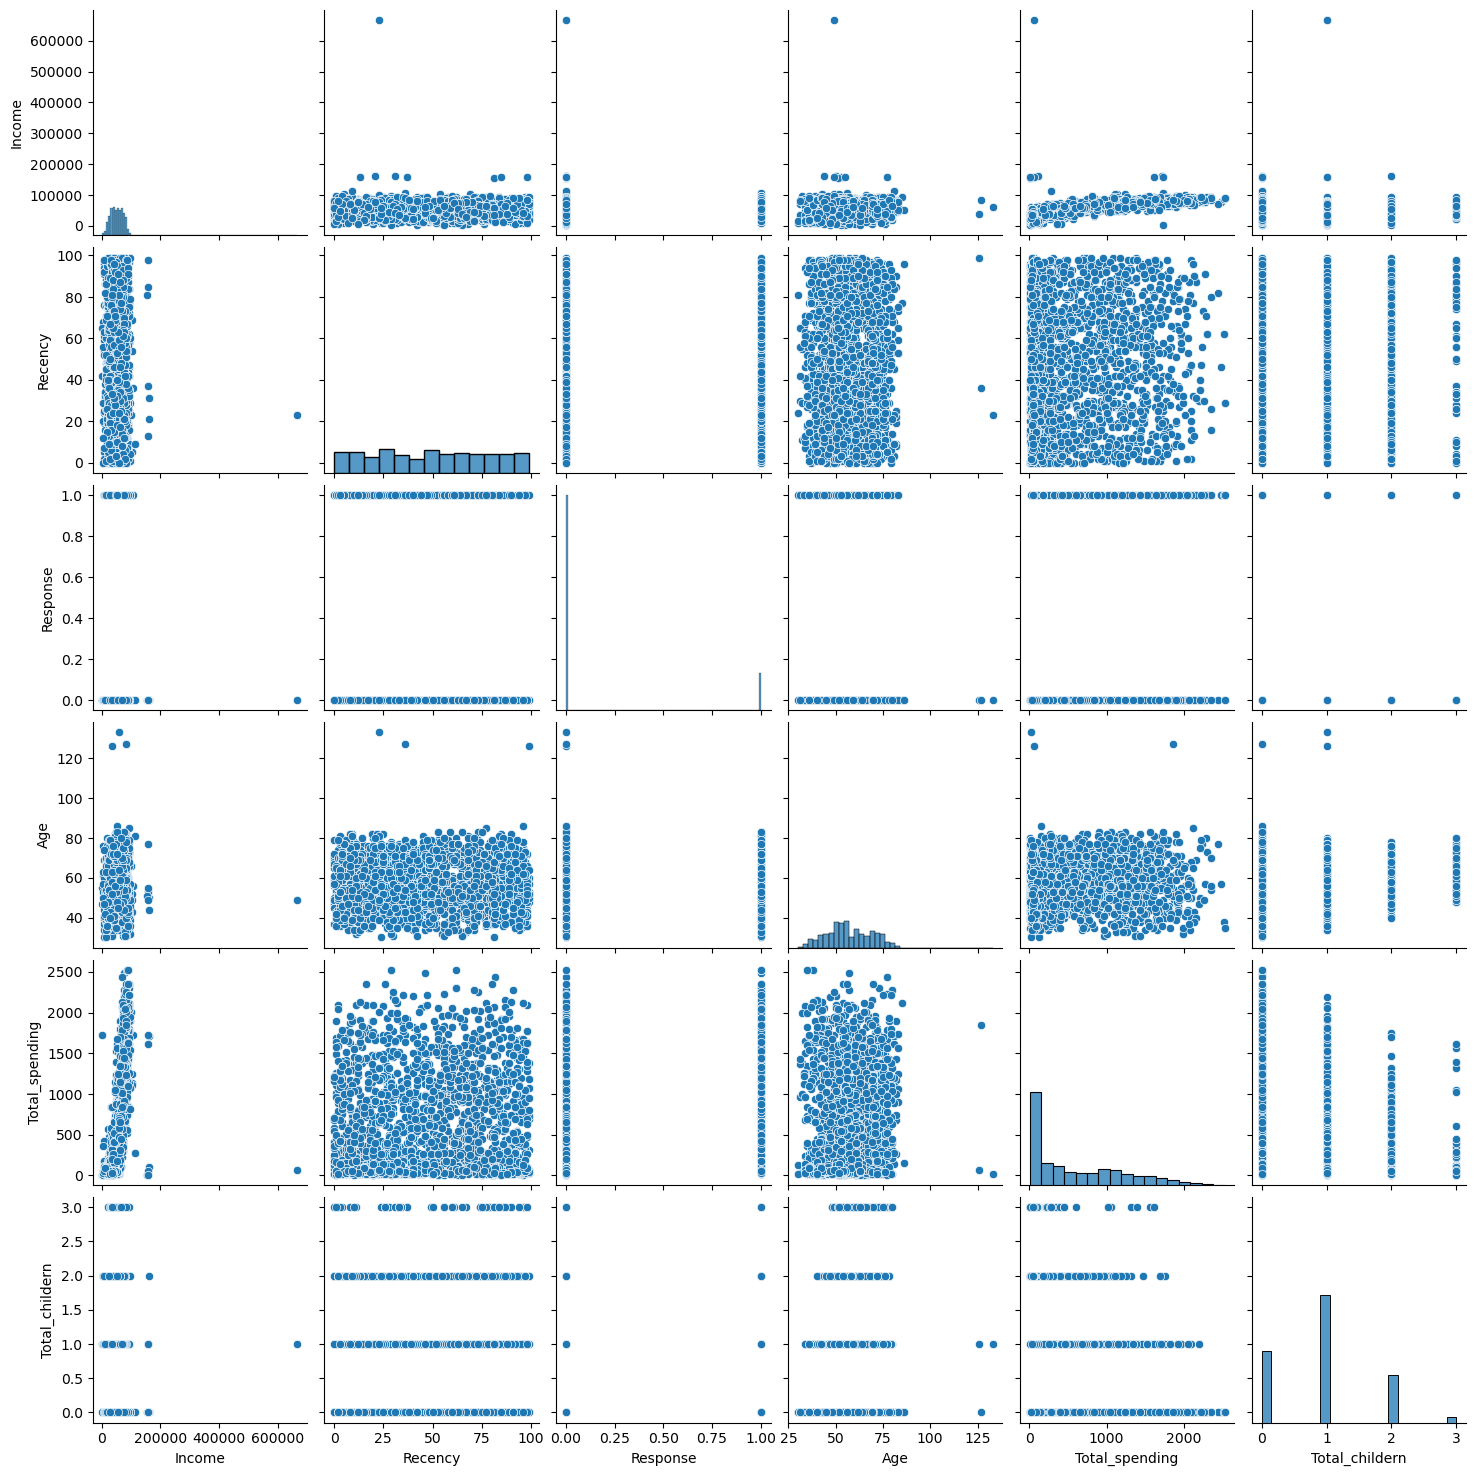

In [15]:
cols = ["Income", "Recency", "Response","Age","Total_spending","Total_childern"]

# Relative Plot
sns.pairplot(
    data_cleaned[cols]
)

In [16]:
# Remove Outliers

print(f"Data size with outliers: {len(data_cleaned)}")

data_cleaned = data_cleaned[(data_cleaned["Age"] < 90)]
data_cleaned = data_cleaned[(data_cleaned["Income"] < 6_00_000)]


print(f"Data size withoutoutliers: {len(data_cleaned)}")

Data size with outliers: 2240
Data size withoutoutliers: 2236


<Axes: >

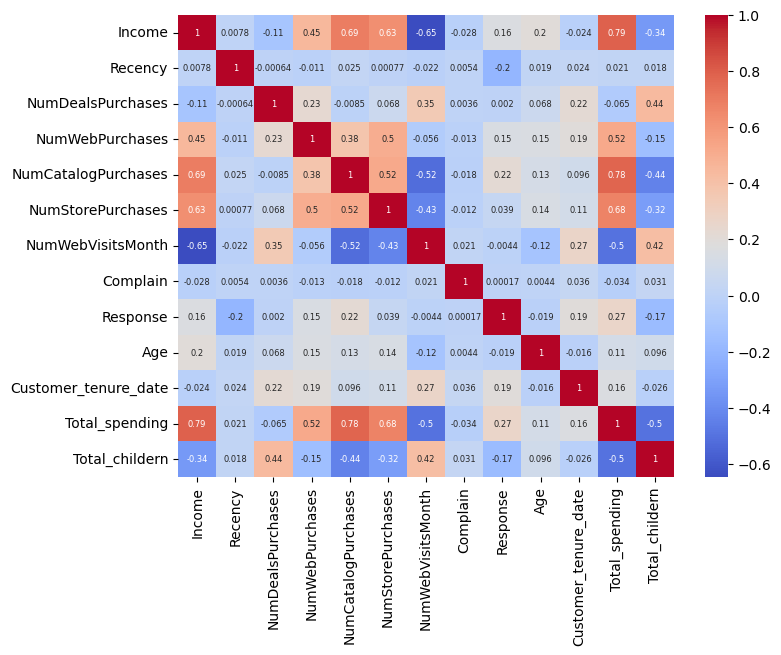

In [17]:
# HeatMap

corr = data_cleaned.corr(numeric_only=1)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

# Feature Encoding 

In [18]:
ohe = OneHotEncoder()
cat_cols = ["Education","Living_with"]

enc_cols = ohe.fit_transform(data_cleaned[cat_cols])

enc_data = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=data_cleaned.index)

data_encoded = pd.concat([data_cleaned.drop(columns=cat_cols),enc_data],axis=1)

print(f"Encoded Data Shape: {data_encoded.shape}")

Encoded Data Shape: (2236, 18)


In [19]:
data_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_date,Total_spending,Total_childern,Education_Graduate,Education_Post,Education_Undergraduate,Living_with_alone,Living_with_partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,0.0,1.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,0.0,1.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [39]:
X = data_encoded

In [48]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualize

(2236, 2)


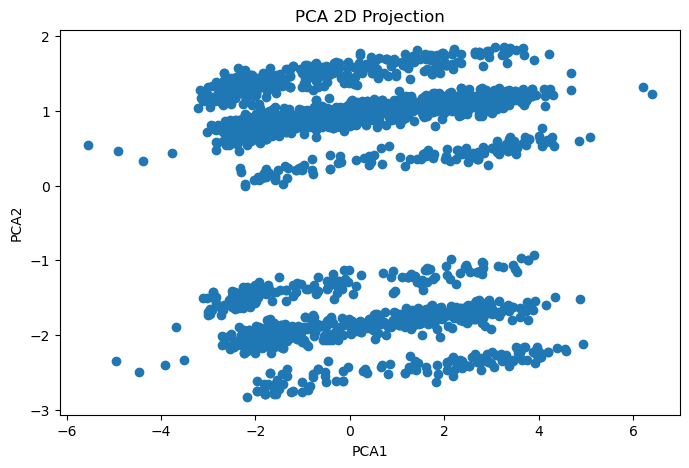

In [49]:
print(X_pca.shape)
plt.figure(figsize=(8, 5))

plt.scatter(X_pca[:, 0], X_pca[:, 1])

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA 2D Projection")
plt.show()

In [50]:
pca.explained_variance_ratio_

array([0.23200912, 0.11419304])

In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

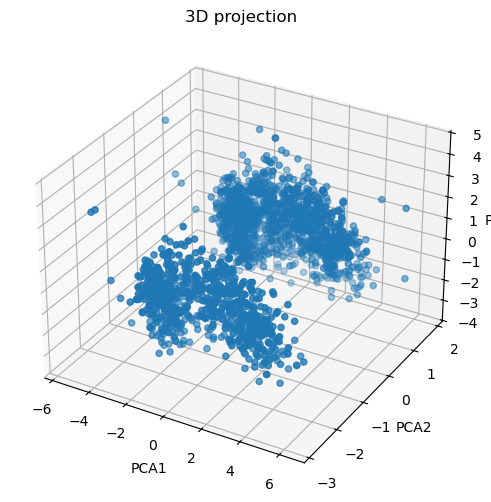

(2236, 3)


In [52]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2]
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")

plt.show()
print(X_pca.shape)

In [44]:
pca.explained_variance_ratio_

array([0.23200912, 0.11419304, 0.10454922])